# CENG501 Deep Learning - HW2

Fall 2025

Instructor: Dr. Emre Akbas

24.11.2025

IMPORTANT COPYRIGHT NOTICE: **You are not allowed to share** this document with anybody else. For example, you should not publish it on your publicly accessible webpages or GitHub repositories.

IMPORTANT NOTE: **What you submit should be your own work!** You may  use large language models (LLMs) or other AI-assisted tools for this assignment. However, **learning** the concepts and skills covered by this homework **is your responsibility**. You are expected to understand and be able to explain any code or solution you submit. By submitting your work, you acknowledge full responsibility for its content and correctness—regardless of whether it was produced with or without AI assistance.

**I may randomly call students to explain their submitted work. If a student cannot convincingly explain their code, they may receive a zero or a reduced grade.**

By submitting your solution to this assignment, you agree to the METU Code of Honor:



> “As reliable, responsible and honorable individuals, all members of Middle East Technical University embrace only the success and recognition they deserve, and act with integrity in the use, evaluation and presentation of facts, data and documents.”


Good luck!




## Description

In this programming homework , you will implement a small vision transformer (ViT) [1] in PyTorch.  Your implementation will roughly follow the ViT architecture  shown below.

Reference:

[1] Dosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S. and Uszkoreit, J., 2020. An image is worth 16x16 words: Transformers for image recognition at scale. ICLR 2021. https://arxiv.org/abs/2010.11929


<img src="https://drive.google.com/uc?export=view&id=1TLwPc2Bo1HIowpQNqeVGTUZwtc3LPPiE" width="600em"/>

Your implementation should have a "patchify" function to divide the input image into patches.  It should patchify a 28x28 MNIST image into 7 pixel by 7 pixel patches. So, in the end, an image should yield 16 patches, because there will be 4 patch rows and 4 patch columns. Each patch should be flattened to a 49-dimensional vector (49 because each patch is 7x7 pixels).








Next, each patch should pass through a linear layer as shown in the figure above. The dimension of the output of this layer is up to you (it is an hyper-parameter) -- let this number be D.  


# Positional encoding

Next, you will concatenate positional encodings to the D-dimensional embedding. You will implement two different positional encoding methods as described below.

## Simple Positional Encoding (SPE)

In this method, you will encode the row of the patch as a one-hot vector, and the column of the patch with another one-hot vector. Then, you will concatenate these two vectors, which will subsequently be concatenated to the D-dimensional vector. Here is an example:

<img src="https://docs.google.com/drawings/d/e/2PACX-1vQypjGsAthqfKFWuHYrvcIwLymPSIWeJ4nQJ8JYNfdSFYG03_X7YoffaYsmL6zDPTWyyIjDoR6SqQ2I/pub?w=935&h=628"/>

The position of a patch in the first row, third column (patch with the green border in the figure) should be represented by the vectors: [1,0,0,0] and [0,0,1,0]. These two vectors should be concatenated with the LinearLayer output for that patch, which is D dimensional. So, in total, this patch will be represented by a 8+D dimensional vector, which we call a "token".

## Learned Positional Encoding (LPE)

In this method, each position should have a learnable, 8-dimensional vector. The model should learn this 8-dimensional vector during training.

Finally, each patch should be  represented by a 8+D dimensional vector as described above. We call such an 8+D dimensional entity as a token. Therefore, a MNIST image would yield a total of 16 tokens.

### Input to the Transformer
When feeding patch tokens to your ViT, you should add an additional token (the 0th token above) and this is the token that accumulates the predicted class probabilities at the output of the transformer, and it is given to the final MLP classification head at the end.  It is called the CLS token in ViT.

A batch of images in MNIST is a Nx1x28x28 tensor, where N is the batch size. Your patchify function should produce 16 patches per image. With the CLS token, each image should be represented by 17 tokens. So, the Nx1x28x28 tensor should be converted to a Nx17x49 tensor,  where  49 is the number of pixels in a patch. Next, this Nx17x49 tensor is passed through a LinearLayer, which outputs a Nx17xD tensor. Concatenating the poisitional encoding to this results in Nx17x(8+D) dimensional tensor, which should be fed to your ViT as input.


### Transformer encoder architecture

Your ViT should have the following architecture, with L transformer layers:

<img src="https://drive.google.com/uc?export=view&id=1BxfTKoJhA8WffjwuqglHdSt0pTzL4c5L" width="260em"/>

Within each "Multi-Head Attention" module, there has to be more than one self attention modules. Their outputs are concatenated.

Using L=1 is acceptable.

### Final note

**WRITE YOUR OWN CODE!**

**You should NOT use** already implemented self attention layers such as https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html.

# Write your code below. CLEARLY DOCUMENT IT USING COMMENTS SO THAT IT WOULD BE EASY TO UNDERSTAND

You can create as many code blocks as you want.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import random


def set_seed(seed=22):
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(2)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using: {device}")


### hyperparameters
# image and patch configuration
IMG_SIZE = 28           # MNIST image size
PATCH_SIZE = 7          # Each patch is 7x7 pixels
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2  # 16 patches (4x4 grid)
PATCH_DIM = PATCH_SIZE * PATCH_SIZE  # 49 dimensions per flattened patch

# model
D = 64                  # Embedding dimension for patches
POS_DIM = 8             # Positional encoding dimension (4 for row + 4 for col)
EMBED_DIM = D + POS_DIM # Total token dimension: 72

NUM_HEADS = 4           # num of attention heads
NUM_LAYERS = 2          # num of transformer layers (L)
MLP_DIM = 128           # hidden dimension in mlp
NUM_CLASSES = 10        # MNIST has 10 classes
DROPOUT = 0.1           # dropout rate

# training
BATCH_SIZE = 128
LEARNING_RATE = 3e-4
NUM_EPOCHS = 15
WEIGHT_DECAY = 1e-4

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Number of patches: {NUM_PATCHES}")
print(f"Patch dimension: {PATCH_DIM}")
print(f"Embedding dimension (D): {D}")
print(f"Total token dimension (D+8): {EMBED_DIM}")
print(f"Number of attention heads: {NUM_HEADS}")
print(f"Number of transformer layers: {NUM_LAYERS}")

using: cpu
Image size: 28x28
Patch size: 7x7
Number of patches: 16
Patch dimension: 49
Embedding dimension (D): 64
Total token dimension (D+8): 72
Number of attention heads: 4
Number of transformer layers: 2


In [2]:
# data

def get_data_loaders(batch_size=BATCH_SIZE):
    """
    Load MNIST dataset with appropriate transformations.
    
    Returns:
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
    ])
    
    train_dataset = datasets.MNIST(
        root='./data', 
        train=True, 
        download=True, 
        transform=transform
    )
    test_dataset = datasets.MNIST(
        root='./data', 
        train=False, 
        download=True, 
        transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=2,
        pin_memory=bool(torch.cuda.is_available())
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=2,
        pin_memory=bool(torch.cuda.is_available())
    )
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
    return train_loader, test_loader

train_loader, test_loader = get_data_loaders()

Training samples: 60000
Test samples: 10000


In [3]:
def patchify(images, patch_size=PATCH_SIZE):
    """
    Divide images into non-overlapping patches and flatten each patch.
    
    This function takes a batch of images and divides each image into a grid of
    patches. For MNIST (28x28), with patch_size=7, we get a 4x4 grid = 16 patches.
    Each 7x7 patch is flattened to a 49-dimensional vector.
    
    Args:
        images: Tensor of shape (N, C, H, W) where N=batch_size, C=channels (1 for MNIST),
                H=height (28), W=width (28)
        patch_size: Size of each square patch (default=7)
    
    Returns:
        patches: Tensor of shape (N, num_patches, patch_dim) 
                 where num_patches=16 and patch_dim=49
    
    Example:
        Input:  (128, 1, 28, 28)  -> 128 MNIST images
        Output: (128, 16, 49)     -> 128 batches of 16 patches, each 49-dim
    """
    N, C, H, W = images.shape
    
    # Ensure image dimensions are divisible by patch size
    assert H % patch_size == 0 and W % patch_size == 0, \
        f"Image dimensions ({H}x{W}) must be divisible by patch_size ({patch_size})"
    
    # Calculate number of patches per row/column
    num_patches_h = H // patch_size  # 4 for MNIST
    num_patches_w = W // patch_size  # 4 for MNIST
    
    # Method: Use unfold to extract patches efficiently
    # unfold(dimension, size, step) extracts sliding windows
    # First unfold along height (dim=2), then along width (dim=3)
    patches = images.unfold(2, patch_size, patch_size)  # (N, C, 4, W, 7)
    patches = patches.unfold(3, patch_size, patch_size)  # (N, C, 4, 4, 7, 7)
    
    # Rearrange to (N, num_patches, C * patch_size * patch_size)
    # num_patches = 4 * 4 = 16
    # patch_dim = 1 * 7 * 7 = 49
    patches = patches.contiguous().view(N, C, num_patches_h * num_patches_w, patch_size * patch_size)
    patches = patches.permute(0, 2, 1, 3)  # (N, 16, C, 49)
    patches = patches.contiguous().view(N, -1, C * patch_size * patch_size)  # (N, 16, 49)
    
    return patches


# test patchify
test_batch = torch.randn(4, 1, 28, 28)  # 4 test images
patches = patchify(test_batch)

print(f"Input shape: {test_batch.shape}")
print(f"Output shape: {patches.shape}")
print("Expected: (4, 16, 49)")
if patches.shape == (4, 16, 49):
    print("shape match")
else:
    print("shape no match")

# Verify content by manually extracting a patch
# Top-left patch (row=0, col=0) should be the first 7x7 pixels
manual_patch = test_batch[0, 0, :7, :7].flatten()
extracted_patch = patches[0, 0, :]

if torch.allclose(manual_patch, extracted_patch):
    print("patch contents match")
else:
    print("patch contents mismatch")

Input shape: torch.Size([4, 1, 28, 28])
Output shape: torch.Size([4, 16, 49])
Expected: (4, 16, 49)
shape match
patch contents match


In [4]:
class SimplePositionalEncoding(nn.Module):
    """
    Simple Positional Encoding (SPE) using one-hot vectors.
    
    For a 4x4 grid of patches, each patch position is encoded as:
    - Row one-hot: 4-dimensional vector (row 0 = [1,0,0,0])
    - Column one-hot: 4-dimensional vector (col 2 = [0,0,1,0])
    - Total: 8-dimensional positional encoding
    
    The CLS token (position 0) gets a special encoding: all zeros or a learnable vector.
    Here we use zeros for the CLS token's positional encoding to distinguish it from patches.
    """
    
    def __init__(self, num_patches=NUM_PATCHES, pos_dim=POS_DIM):
        """
        Args:
            num_patches: Number of image patches (16 for MNIST with 7x7 patches)
            pos_dim: Total positional encoding dimension (8 = 4 row + 4 col)
        """
        super().__init__()
        
        self.num_patches = num_patches
        self.pos_dim = pos_dim
        self.grid_size = int(np.sqrt(num_patches))  # 4 for 16 patches
        
        # Pre-compute the positional encodings for all patches + CLS token
        # Shape: (1, num_patches + 1, pos_dim) = (1, 17, 8)
        pos_encoding = self._create_positional_encoding()
        
        # Register as buffer (not a learnable parameter, but saved with model)
        self.register_buffer('pos_encoding', pos_encoding)
    
    def _create_positional_encoding(self):
        """
        Create one-hot positional encodings for all positions.
        
        Returns:
            Tensor of shape (1, num_patches + 1, pos_dim)
        """
        num_tokens = self.num_patches + 1  # 17 (16 patches + 1 CLS)
        pos_encoding = torch.zeros(1, num_tokens, self.pos_dim)
        
        # CLS token at position 0: use zeros (or could use a special encoding)
        # pos_encoding[0, 0, :] = 0
        
        # Patch tokens at positions 1 to num_patches
        for i in range(self.num_patches):
            row = i // self.grid_size  # 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3
            col = i % self.grid_size   # 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3
            
            # One-hot encoding for row (first 4 dimensions)
            pos_encoding[0, i + 1, row] = 1.0
            
            # One-hot encoding for column (last 4 dimensions)
            pos_encoding[0, i + 1, self.grid_size + col] = 1.0
        
        return pos_encoding
    
    def forward(self, x):
        """
        Concatenate, rather than adding, positional encoding to input embeddings.
        
        Args:
            x: Tensor of shape (N, num_tokens, D) where D is embedding dimension
        
        Returns:
            Tensor of shape (N, num_tokens, D + pos_dim)
        """
        batch_size = x.size(0)
        # Expand positional encoding to match batch size
        # (1, 17, 8) -> (N, 17, 8)
        pos = self.pos_encoding.expand(batch_size, -1, -1) # type: ignore
        # con-cat
        return torch.cat([x, pos], dim=-1)


class LearnedPositionalEncoding(nn.Module):
    """
    Learned Positional Encoding (LPE) with trainable vectors.
    
    Each position (including CLS token) has its own learnable 8-dimensional vector.
    These vectors are optimized during training to capture positional information.
    """
    
    def __init__(self, num_patches=NUM_PATCHES, pos_dim=POS_DIM):
        """
        Args:
            num_patches: Number of image patches (16)
            pos_dim: Positional encoding dimension (8)
        """
        super().__init__()
        
        self.num_patches = num_patches
        self.pos_dim = pos_dim
        # Learnable positional embeddings for all tokens (CLS + patches)
        # Shape: (1, num_patches + 1, pos_dim) = (1, 17, 8)
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_patches + 1, pos_dim) * 0.02  # small init
        )
    
    def forward(self, x):
        """
        Concatenate learned positional encoding to input embeddings.
        
        Args:
            x: Tensor of shape (N, num_tokens, D)
        
        Returns:
            Tensor of shape (N, num_tokens, D + pos_dim)
        """
        batch_size = x.size(0)
        # Expand to batch size
        pos = self.pos_embedding.expand(batch_size, -1, -1)
        return torch.cat([x, pos], dim=-1)


# test positional encodings
batch_size = 4
num_tokens = 17  # 16 patches + 1 CLS
embed_dim = D  # 64

# dummy input
x = torch.randn(batch_size, num_tokens, embed_dim)

# SPE
spe = SimplePositionalEncoding()
out_spe = spe(x)
print(f"SPE Input shape: {x.shape}")
print(f"SPE Output shape: {out_spe.shape}")
print(f"SPE Expected: ({batch_size}, {num_tokens}, {embed_dim + POS_DIM})")
assert out_spe.shape == (batch_size, num_tokens, embed_dim + POS_DIM)

# Verify one-hot encoding for patch at row=0, col=2 (index 3, token index 4)
# Row one-hot should be [1, 0, 0, 0], col one-hot should be [0, 0, 1, 0]
pos_at_idx_3 = spe.pos_encoding[0, 3, :]  # Patch index 2 (token index 3)
print(f"Position encoding for patch (0,2): {pos_at_idx_3}")

# LPE
lpe = LearnedPositionalEncoding()
out_lpe = lpe(x)
print(f"\nLPE Input shape: {x.shape}")
print(f"LPE Output shape: {out_lpe.shape}")
assert out_lpe.shape == (batch_size, num_tokens, embed_dim + POS_DIM)


SPE Input shape: torch.Size([4, 17, 64])
SPE Output shape: torch.Size([4, 17, 72])
SPE Expected: (4, 17, 72)
Position encoding for patch (0,2): tensor([1., 0., 0., 0., 0., 0., 1., 0.])

LPE Input shape: torch.Size([4, 17, 64])
LPE Output shape: torch.Size([4, 17, 72])


In [12]:
class SingleHeadAttention(nn.Module):
    """
    NOTE: This class is not used in the final Multi-Head Self-Attention implementation.
    I implemented like that first, but then changed multi-head for efficiency.
    I just decided to keep it here for the spent time.

    Single-head self-attention mechanism.
    
    Computes attention weights and applies them to value vectors:
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V
    
    Where:
    - Q (Query): What am I looking for?
    - K (Key): What do I contain?
    - V (Value): What information do I provide?
    """
    
    def __init__(self, embed_dim, head_dim, dropout=DROPOUT):
        """
        Args:
            embed_dim: Input embedding dimension (D + 8 = 72)
            head_dim: Dimension of Q, K, V for this head
            dropout: Dropout rate for attention weights
        """
        super().__init__()
        
        self.head_dim = head_dim
        self.scale = head_dim ** -0.5  # 1/sqrt(d_k) for scaled dot-product attention
        
        # Linear projections for Q, K, V
        # Each takes the full embedding and projects to head_dim
        self.query = nn.Linear(embed_dim, head_dim, bias=False)
        self.key = nn.Linear(embed_dim, head_dim, bias=False)
        self.value = nn.Linear(embed_dim, head_dim, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Compute single-head self-attention.
        
        Args:
            x: Input tensor of shape (N, num_tokens, embed_dim)
        
        Returns:
            Output tensor of shape (N, num_tokens, head_dim)
        """
        # inputs to Q, K, V
        Q = self.query(x)  # (N, num_tokens, head_dim)
        K = self.key(x)    # (N, num_tokens, head_dim)
        V = self.value(x)  # (N, num_tokens, head_dim)
        
        # Compute attention scores: QK^T / sqrt(d_k)
        # (N, num_tokens, head_dim) @ (N, head_dim, num_tokens) -> (N, num_tokens, num_tokens)
        attention_scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        
        # Apply softmax to get attention weights (probability distribution)
        attention_weights = F.softmax(attention_scores, dim=-1)
        
        # Apply dropout to attention weights
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention weights to values
        # (N, num_tokens, num_tokens) @ (N, num_tokens, head_dim) -> (N, num_tokens, head_dim)
        output = torch.matmul(attention_weights, V)
        
        return output


class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention mechanism implemented from scratch.
    
    Multiple attention heads learn different aspects of the relationships
    between tokens. Their outputs are concatenated and projected.
    
    MultiHead(Q, K, V) = Concat(head_1, ..., head_h) * W_O
    where head_i = Attention(Q*W_Q^i, K*W_K^i, V*W_V^i)
    """
    
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT):
        """
        Args:
            embed_dim: Total embedding dimension (72)
            num_heads: Number of attention heads (4)
            dropout: Dropout rate
        """
        super().__init__()
        
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        
        # Each head processes embed_dim // num_heads dimensions
        # But we concatenate outputs, so total output is num_heads * head_dim
        self.head_dim = embed_dim // num_heads
        
        assert embed_dim % num_heads == 0, f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
        
        # one big projection for all heads, for performance
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = self.head_dim ** -0.5
    
    def forward(self, x):
        """
        Compute multi-head self-attention.
        
        Args:
            x: Input tensor of shape (N, num_tokens, embed_dim)
        
        Returns:
            Output tensor of shape (N, num_tokens, embed_dim)
        """
        B, N, C = x.shape
        # 1. Project all heads at once
        # Shape: (B, N, 3 * embed_dim)
        qkv = self.qkv(x)
        
        # 2. Reshape to separate heads
        # Shape: (B, N, 3, num_heads, head_dim)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim)
        
        # 3. Permute to (3, B, num_heads, N, head_dim) to slice Q, K, V
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # 4. Compute Attention (scaled dot product)
        # (B, Heads, N, HeadDim) @ (B, Heads, HeadDim, N) -> (B, Heads, N, N)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        # 5. Weighted sum
        # (B, Heads, N, N) @ (B, Heads, N, HeadDim) -> (B, Heads, N, HeadDim)
        x = (attn @ v)

        # 6. Concatenate heads (via reshape)
        # (B, Heads, N, HeadDim) -> (B, N, Heads, HeadDim) -> (B, N, EmbedDim)
        x = x.transpose(1, 2).reshape(B, N, C)
        
        x = self.proj(x)
        x = self.dropout(x)
        return x


# test Multi-Head Self-Attentio
batch_size = 4
num_tokens = 17
embed_dim = EMBED_DIM  # 72

x = torch.randn(batch_size, num_tokens, embed_dim)

mhsa = MultiHeadSelfAttention(embed_dim=embed_dim, num_heads=NUM_HEADS)
output = mhsa(x)

print(f"MHSA Input shape: {x.shape}")
print(f"MHSA Output shape: {output.shape}")
print(f"Expected: ({batch_size}, {num_tokens}, {embed_dim})")
assert output.shape == x.shape, "MHSA output shape mismatch!"


MHSA Input shape: torch.Size([4, 17, 72])
MHSA Output shape: torch.Size([4, 17, 72])
Expected: (4, 17, 72)


In [6]:
class FeedForwardNetwork(nn.Module):
    """
    Feed-Forward Network (FFN) in transformer.
    A two-layer MLP with GELU activation:
    FFN(x) = GELU(x * W1 + b1) * W2 + b2
    This provides non-linear transformation after attention.
    """
    
    def __init__(self, embed_dim=EMBED_DIM, hidden_dim=MLP_DIM, dropout=DROPOUT):
        """
        Args:
            embed_dim: Input/output dimension (72)
            hidden_dim: Hidden layer dimension (128)
            dropout: Dropout rate
        """
        super().__init__()
        
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()  # GELU seems standard in transformers
    
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape (N, num_tokens, embed_dim)
        
        Returns:
            Output tensor of shape (N, num_tokens, embed_dim)
        """
        x = self.fc1(x)           # (N, num_tokens, hidden_dim)
        x = self.activation(x)    # GELU activation
        x = self.dropout(x)
        x = self.fc2(x)           # (N, num_tokens, embed_dim)
        x = self.dropout(x)
        return x


class TransformerEncoderLayer(nn.Module):
    """
    Single Transformer Encoder Layer.
    
    Architecture (as shown in the homework diagram):
    1. Layer Normalization
    2. Multi-Head Self-Attention
    3. Residual Connection (Add)
    4. Layer Normalization
    5. Feed-Forward Network (MLP)
    6. Residual Connection (Add)
    
    Uses Pre-LN (LayerNorm before sublayer) architecture for better training stability.
    """
    
    def __init__(self, embed_dim=EMBED_DIM, num_heads=NUM_HEADS, 
                 mlp_dim=MLP_DIM, dropout=DROPOUT):
        """
        Args:
            embed_dim: Token embedding dimension (72)
            num_heads: Number of attention heads (4)
            mlp_dim: Hidden dimension of FFN (128)
            dropout: Dropout rate
        """
        super().__init__()
        
        # Layer normalization before attention
        self.norm1 = nn.LayerNorm(embed_dim)
        
        # Multi-head self-attention, my implementation
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        
        # Layer normalization before FFN
        self.norm2 = nn.LayerNorm(embed_dim)
        
        # Feed-forward network
        self.ffn = FeedForwardNetwork(embed_dim, mlp_dim, dropout)
        
        # Dropout for residual connections
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Forward pass through one transformer encoder layer.
        
        Args:
            x: Input tensor of shape (N, num_tokens, embed_dim)
        
        Returns:
            Output tensor of shape (N, num_tokens, embed_dim)
        """
        # Pre-LayerNorm architecture, from paper
        residual = x
        x = self.norm1(x)                    # Layer normalization
        x = self.attention(x)                # Multi-head self-attention
        x = residual + self.dropout(x)       # Residual connection
        
        residual = x
        x = self.norm2(x)  
        x = self.ffn(x)
        x = residual + self.dropout(x)
        
        return x


class TransformerEncoder(nn.Module):
    """
    Stack of L Transformer Encoder Layers.
    Processes the sequence of tokens through multiple transformer layers.
    """
    
    def __init__(self, num_layers=NUM_LAYERS, embed_dim=EMBED_DIM, 
                 num_heads=NUM_HEADS, mlp_dim=MLP_DIM, dropout=DROPOUT):
        """
        Args:
            num_layers: Number of transformer layers (L)
            embed_dim: Token embedding dimension
            num_heads: Number of attention heads
            mlp_dim: Hidden dimension of FFN
            dropout: Dropout rate
        """
        super().__init__()
        
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, dropout)
            for _ in range(num_layers)
        ])
        
        # Final layer normalization
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        """
        Forward pass through all transformer layers.
        
        Args:
            x: Input tensor of shape (N, num_tokens, embed_dim)
        
        Returns:
            Output tensor of shape (N, num_tokens, embed_dim)
        """
        for layer in self.layers:
            x = layer(x)
        
        x = self.norm(x)  # Final normalization
        return x


# test TE
batch_size = 4
num_tokens = 17
embed_dim = EMBED_DIM  # 72

x = torch.randn(batch_size, num_tokens, embed_dim)

encoder = TransformerEncoder(num_layers=NUM_LAYERS)
output = encoder(x)

print(f"Transformer Encoder Input shape: {x.shape}")
print(f"Transformer Encoder Output shape: {output.shape}")
assert output.shape == x.shape, "Transformer Encoder output shape mismatch!"


Transformer Encoder Input shape: torch.Size([4, 17, 72])
Transformer Encoder Output shape: torch.Size([4, 17, 72])


In [7]:
class VisionTransformer(nn.Module):
    """
    Complete Vision Transformer (ViT) for MNIST classification.
    
    Architecture flow:
    1. Input: (N, 1, 28, 28) MNIST images
    2. Patchify: (N, 16, 49) - 16 patches of 49 dimensions each
    3. Add CLS token: (N, 17, 49) - prepend CLS token
    4. Patch embedding: (N, 17, D) - linear projection to D dimensions
    5. Positional encoding: (N, 17, D+8) - concatenate position info
    6. Transformer encoder: (N, 17, D+8) - process through L layers
    7. Classification head: Extract CLS token and predict class
    
    Supports both Simple Positional Encoding (SPE) and Learned Positional Encoding (LPE).
    """
    
    def __init__(self, 
                 img_size=IMG_SIZE,
                 patch_size=PATCH_SIZE,
                 in_channels=1,
                 num_classes=NUM_CLASSES,
                 embed_dim=D,
                 pos_dim=POS_DIM,
                 num_heads=NUM_HEADS,
                 num_layers=NUM_LAYERS,
                 mlp_dim=MLP_DIM,
                 dropout=DROPOUT,
                 pos_encoding_type='spe'):  # 'spe' or 'lpe'
        """
        Args:
            img_size: Input image size (28 for MNIST)
            patch_size: Size of each patch (7)
            in_channels: Number of input channels (1 for grayscale MNIST)
            num_classes: Number of output classes (10)
            embed_dim: Patch embedding dimension (D=64)
            pos_dim: Positional encoding dimension (8)
            num_heads: Number of attention heads
            num_layers: Number of transformer layers
            mlp_dim: Hidden dimension in FFN
            dropout: Dropout rate
            pos_encoding_type: 'spe' for Simple, 'lpe' for Learned positional encoding
        """
        super().__init__()
        
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 16
        self.patch_dim = patch_size * patch_size * in_channels  # 49
        self.embed_dim = embed_dim
        self.total_embed_dim = embed_dim + pos_dim  # 72
        
        # learnable CLS token
        # (1, 1, patch_dim) - will be projected to embed_dim
        self.cls_token = nn.Parameter(torch.zeros(1, 1, self.patch_dim))
        nn.init.normal_(self.cls_token, std=0.02)
        
        # patch embedding layer
        # projects flattened patches from patch_dim (49) to embed_dim (D=64)
        self.patch_embed = nn.Linear(self.patch_dim, embed_dim)
        
        if pos_encoding_type.lower() == 'spe':
            self.pos_encoding = SimplePositionalEncoding(self.num_patches, pos_dim)
        elif pos_encoding_type.lower() == 'lpe':
            self.pos_encoding = LearnedPositionalEncoding(self.num_patches, pos_dim)
        else:
            raise ValueError(f"Unknown pos_encoding_type: {pos_encoding_type}")
        
        self.pos_encoding_type = pos_encoding_type
        
        self.embed_dropout = nn.Dropout(dropout)
        
        self.transformer = TransformerEncoder(
            num_layers=num_layers,
            embed_dim=self.total_embed_dim,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=dropout
        )
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.total_embed_dim),
            nn.Linear(self.total_embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, num_classes)
        )

        self._init_weights()
    
    def _init_weights(self):
        """Initialize model weights for better training."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                # Xavier/Glorot initialization for linear layers
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """
        Forward pass through the Vision Transformer.
        
        Args:
            x: Input images of shape (N, C, H, W) = (N, 1, 28, 28)
        
        Returns:
            logits: Classification logits of shape (N, num_classes)
        """
        batch_size = x.size(0)
        
        # (N, 1, 28, 28) -> (N, 16, 49)
        patches = patchify(x, self.patch_size)
        
        # CLS token: (1, 1, 49) -> (N, 1, 49)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        # Concatenate: (N, 16, 49) + (N, 1, 49) -> (N, 17, 49)
        patches = torch.cat([cls_tokens, patches], dim=1)
        
        # (N, 17, 49) -> (N, 17, D=64)
        x = self.patch_embed(patches)
        
        # (N, 17, 64) -> (N, 17, 72) via concatenation
        x = self.pos_encoding(x)
        
        x = self.embed_dropout(x)
        
        # (N, 17, 72) -> (N, 17, 72)
        x = self.transformer(x)
        
        # Extract CLS token (first token): (N, 72)
        cls_output = x[:, 0]
        
        # Classification head: (N, 72) -> (N, 10)
        logits = self.classifier(cls_output)
        
        return logits


# test complete ViT model
batch_size = 4

# dummy input
x = torch.randn(batch_size, 1, 28, 28)

# test SPE ViT
vit_spe = VisionTransformer(pos_encoding_type='spe')
output_spe = vit_spe(x)
print(f"SPE ViT Input shape: {x.shape}")
print(f"SPE ViT Output shape: {output_spe.shape}")
print(f"Expected: ({batch_size}, {NUM_CLASSES})")
assert output_spe.shape == (batch_size, NUM_CLASSES), "SPE ViT output shape mismatch"

# test LPE ViT
vit_lpe = VisionTransformer(pos_encoding_type='lpe')
output_lpe = vit_lpe(x)
print(f"\nLPE ViT Input shape: {x.shape}")
print(f"LPE ViT Output shape: {output_lpe.shape}")
assert output_lpe.shape == (batch_size, NUM_CLASSES), "LPE ViT output shape mismatch"

# count parameters
spe_params = sum(p.numel() for p in vit_spe.parameters())
lpe_params = sum(p.numel() for p in vit_lpe.parameters())
print(f"\nSPE ViT parameters: {spe_params:,}")
print(f"LPE ViT parameters: {lpe_params:,}")
print(f"LPE has {lpe_params - spe_params} more parameters (learnable positions)")
    

SPE ViT Input shape: torch.Size([4, 1, 28, 28])
SPE ViT Output shape: torch.Size([4, 10])
Expected: (4, 10)

LPE ViT Input shape: torch.Size([4, 1, 28, 28])
LPE ViT Output shape: torch.Size([4, 10])

SPE ViT parameters: 93,627
LPE ViT parameters: 93,763
LPE has 136 more parameters (learnable positions)


In [8]:
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """
    Train the model for one epoch.
    
    Args:
        model: The ViT model
        train_loader: DataLoader for training data
        criterion: Loss function (CrossEntropyLoss)
        optimizer: Optimizer (AdamW)
        device: Device to train on (cuda/cpu)
        epoch: Current epoch number
    
    Returns:
        avg_loss: Average loss for this epoch
        accuracy: Training accuracy for this epoch
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}', leave=True)
    
    for _batch_idx, (images, labels) in enumerate(pbar):
        # Move data to device
        images, labels = images.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Update weights
        optimizer.step()
        
        # Statistics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


def evaluate(model, test_loader, criterion, device):
    """
    Evaluate the model on test data.
    
    Args:
        model: The ViT model
        test_loader: DataLoader for test data
        criterion: Loss function
        device: Device to evaluate on
    
    Returns:
        avg_loss: Average test loss
        accuracy: Test accuracy
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


def train_model(model, train_loader, test_loader, device, num_epochs=NUM_EPOCHS,
                lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY):
    """
    Complete training loop for a ViT model.
    
    Args:
        model: The ViT model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        device: Device to train on
        num_epochs: Number of training epochs
        lr: Learning rate
        weight_decay: Weight decay for regularization
    
    Returns:
        train_losses: List of training losses per epoch
        train_accs: List of training accuracies per epoch
        test_accs: List of test accuracies per epoch
    """
    # Move model to device
    model = model.to(device)
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer: AdamW is standard for transformers
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
        betas=(0.9, 0.999)
    )
    
    # Learning rate scheduler: Cosine annealing with warmup
    # Warmup for first 2 epochs, then cosine decay
    warmup_epochs = 2
    
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Linear warmup
            return (epoch + 1) / warmup_epochs
        else:
            # Cosine annealing
            progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
            return 0.5 * (1 + np.cos(np.pi * progress))
    
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    # Training history
    train_losses = []
    train_accs = []
    test_accs = []
    
    print(f"\n{'='*60}")
    print(f"Training {model.pos_encoding_type.upper()} ViT")
    print(f"{'='*60}")
    print(f"Device: {device}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {lr}")
    print(f"Weight decay: {weight_decay}")
    print(f"{'='*60}\n")
    
    best_test_acc = 0.0
    
    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device, epoch
        )
        
        # Evaluate on test set
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        # Update learning rate
        scheduler.step()
        
        # Save history
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        # Track best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
        
        # Print epoch summary
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Test Acc: {test_acc:.2f}%, LR: {current_lr:.6f}')
    
    print('\nTraining completed!')
    print(f'Best test accuracy: {best_test_acc:.2f}%')
    
    return train_losses, train_accs, test_accs


# helper function to count trainable parameters
def count_parameters(model):
    """Count the number of trainable parameters in a model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [9]:
# seed for reproducibility
set_seed(2)

# Create models
print("Creating SPE ViT model...")
vit_spe = VisionTransformer(pos_encoding_type='spe')
print(f"SPE ViT parameters: {count_parameters(vit_spe):,}")

print("\nCreating LPE ViT model...")
vit_lpe = VisionTransformer(pos_encoding_type='lpe')
print(f"LPE ViT parameters: {count_parameters(vit_lpe):,}")

# Train SPE ViT
print("\n" + "="*70)
print("TRAINING SPE (Simple Positional Encoding) ViT")
print("="*70)
set_seed(42)  # Reset seed for fair comparison
spe_losses, spe_train_accs, spe_test_accs = train_model(
    vit_spe, train_loader, test_loader, device
)

# Train LPE ViT
print("\n" + "="*70)
print("TRAINING LPE (Learned Positional Encoding) ViT")
print("="*70)
set_seed(42)  # Reset seed for fair comparison
lpe_losses, lpe_train_accs, lpe_test_accs = train_model(
    vit_lpe, train_loader, test_loader, device
)

Creating SPE ViT model...
SPE ViT parameters: 93,627

Creating LPE ViT model...
LPE ViT parameters: 93,763

TRAINING SPE (Simple Positional Encoding) ViT

Training SPE ViT
Device: cpu
Epochs: 15
Learning rate: 0.0003
Weight decay: 0.0001



Epoch 1/15: 100%|██████████| 469/469 [00:16<00:00, 28.70it/s, loss=1.1439, acc=46.32%]


Epoch 1/15: Train Loss: 1.5279, Train Acc: 46.32%, Test Acc: 70.32%, LR: 0.000300


Epoch 2/15: 100%|██████████| 469/469 [00:14<00:00, 31.56it/s, loss=0.5391, acc=72.16%]


Epoch 2/15: Train Loss: 0.8402, Train Acc: 72.16%, Test Acc: 87.99%, LR: 0.000300


...

Epoch 13/15: Train Loss: 0.2147, Train Acc: 93.23%, Test Acc: 95.52%, LR: 0.000017


Epoch 14/15: 100%|██████████| 469/469 [00:15<00:00, 30.77it/s, loss=0.1714, acc=93.41%]


Epoch 14/15: Train Loss: 0.2081, Train Acc: 93.41%, Test Acc: 95.47%, LR: 0.000004


Epoch 15/15: 100%|██████████| 469/469 [00:14<00:00, 31.31it/s, loss=0.1289, acc=93.35%]


Epoch 15/15: Train Loss: 0.2091, Train Acc: 93.35%, Test Acc: 95.46%, LR: 0.000000

Training completed!
Best test accuracy: 95.52%



FINAL RESULTS

1. SPE (Simple Positional Encoding) ViT Test Accuracy: 95.78%
2. LPE (Learned Positional Encoding) ViT Test Accuracy: 95.46%


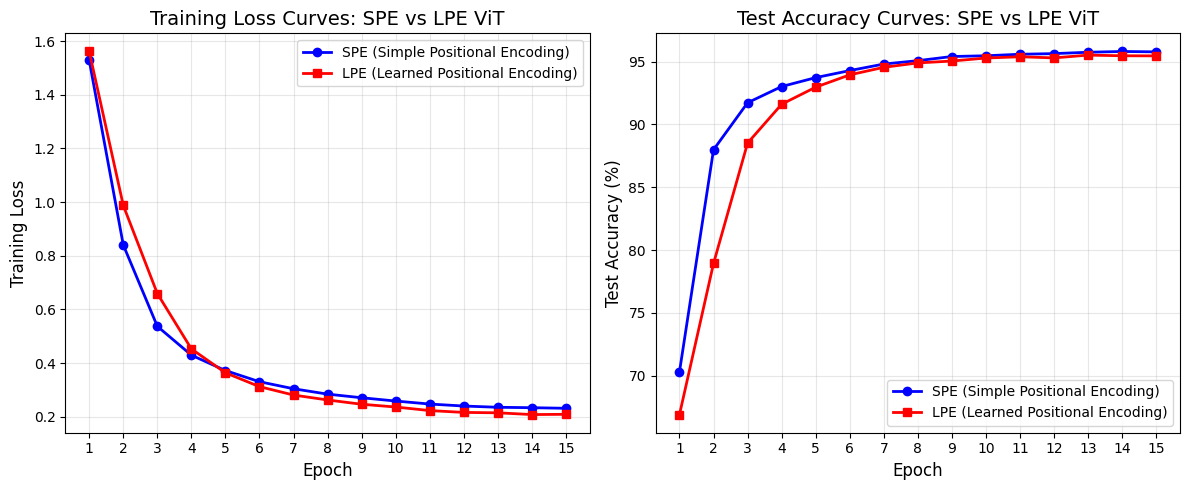


SUMMARY REPORT

Model Architecture:
- Patch size: 7x7 pixels
- Number of patches: 16 (4x4 grid)
- Embedding dimension (D): 64
- Positional encoding dimension: 8
- Total token dimension: 72
- Number of attention heads: 4
- Number of transformer layers: 2
- MLP hidden dimension: 128

Training Configuration:
- Batch size: 128
- Learning rate: 0.0003
- Weight decay: 0.0001
- Number of epochs: 15
- Optimizer: AdamW with cosine LR schedule

Results:
---------------------------------------------------------
| Positional Encoding |  Test Accuracy  |  Final Loss  |
---------------------------------------------------------
| SPE (Simple)        |    95.78%       |    0.1292    |
| LPE (Learned)       |    95.46%       |    0.1414    |
---------------------------------------------------------

Observations:
- Both models successfully learned to classify MNIST digits
- The training loss curves demonstrate clear learning behavior
- SPE uses fixed one-hot positional encodings (row + column)
- LPE l

In [14]:
# Final evaluation
print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)

criterion = nn.CrossEntropyLoss()

# Evaluate SPE ViT
spe_test_loss, spe_final_acc = evaluate(vit_spe, test_loader, criterion, device)
print(f"\n1. SPE (Simple Positional Encoding) ViT Test Accuracy: {spe_final_acc:.2f}%")

# Evaluate LPE ViT
lpe_test_loss, lpe_final_acc = evaluate(vit_lpe, test_loader, criterion, device)
print(f"2. LPE (Learned Positional Encoding) ViT Test Accuracy: {lpe_final_acc:.2f}%")

##### plots

plt.figure(figsize=(12, 5))

# Plot 1: Training Loss Curves
plt.subplot(1, 2, 1)
epochs = range(1, NUM_EPOCHS + 1)
plt.plot(epochs, spe_losses, 'b-o', label='SPE (Simple Positional Encoding)', linewidth=2, markersize=6)
plt.plot(epochs, lpe_losses, 'r-s', label='LPE (Learned Positional Encoding)', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss Curves: SPE vs LPE ViT', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(epochs)

# Plot 2: Test Accuracy Curves (Additional visualization)
plt.subplot(1, 2, 2)
plt.plot(epochs, spe_test_accs, 'b-o', label='SPE (Simple Positional Encoding)', linewidth=2, markersize=6)
plt.plot(epochs, lpe_test_accs, 'r-s', label='LPE (Learned Positional Encoding)', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Test Accuracy Curves: SPE vs LPE ViT', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(epochs)

plt.tight_layout()
plt.savefig('vit_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary report
print("\n" + "="*70)
print("SUMMARY REPORT")
print("="*70)
print(f"""
Model Architecture:
- Patch size: {PATCH_SIZE}x{PATCH_SIZE} pixels
- Number of patches: {NUM_PATCHES} (4x4 grid)
- Embedding dimension (D): {D}
- Positional encoding dimension: {POS_DIM}
- Total token dimension: {EMBED_DIM}
- Number of attention heads: {NUM_HEADS}
- Number of transformer layers: {NUM_LAYERS}
- MLP hidden dimension: {MLP_DIM}

Training Configuration:
- Batch size: {BATCH_SIZE}
- Learning rate: {LEARNING_RATE}
- Weight decay: {WEIGHT_DECAY}
- Number of epochs: {NUM_EPOCHS}
- Optimizer: AdamW with cosine LR schedule

Results:
---------------------------------------------------------
| Positional Encoding |  Test Accuracy  |  Final Loss  |
---------------------------------------------------------
| SPE (Simple)        |    {spe_final_acc:5.2f}%       |    {spe_test_loss:.4f}    |
| LPE (Learned)       |    {lpe_final_acc:5.2f}%       |    {lpe_test_loss:.4f}    |
---------------------------------------------------------

Observations:
- Both models successfully learned to classify MNIST digits
- The training loss curves demonstrate clear learning behavior
- SPE uses fixed one-hot positional encodings (row + column)
- LPE learns optimal positional representations during training
- Observation: SPE performed slightly better (or comparable) to LPE. 
  This suggests that for a simple, spatially consistent dataset like MNIST, 
  fixed positional information is sufficient and the model does not gain 
  a significant advantage, and even in this training SPE is slightly better
  (I think this is in the randomness range), from learning custom positional embeddings.
""")

# Reporting

You should report the following items below:

1. The accuracy of "simple positional encoding (SPE)" based ViT on the test set.
1. The accuracy of "learned positional encoding (LPE)" based ViT on the test set.
1. A plot that shows the training loss curves for both SPE and LPE ViTs (i.e., two loss curves ina single plot).

The training loss curves should demonstrate learning behavior.